# ex-h2 — the two-factor radar, and what it shows about hedging

A deliberately small, self-contained $k=2$ disk. It borrows the *picture* from
`notebooks/ex-10_two_factor_paired_radar_sharedB` but none of its machinery — no
gauge-scrambling study, no paired-replicate tracking, no shrink-factor algebra.
One model, one sweep, four figures.

**Why $k=2$ is the right place to look.** The true factor subspace
$\mathcal{B}=\mathrm{span}(\bar b_1,\bar b_2)$ is a single *plane*, so the disk below
**is** that plane, drawn in the $(\bar b_1,\bar b_2)$ basis. Each estimated direction
$h_j$ appears as its projection $\Pi_{\mathcal B}h_j$, at coordinates
$(\langle\bar b_1,h_j\rangle, \langle\bar b_2,h_j\rangle)$. Nothing hides in a third
coordinate: the radius is exactly the in-subspace mass,

$$\lVert \Pi_{\mathcal B}h_j\rVert^2 = 1-\lVert\Pi^{\perp}h_j\rVert^2,$$

so the **gap from the arrow tip to the unit circle is the out-of-subspace error** —
the part a block hedge must pay — and the **angle between the two arrows and the axes**
is the in-plane rotation — the part it escapes.

Everything is the $2\times2$ matrix $C=\bar B H$, whose column $j$ is the plotted
arrow. Rotating the estimated frame sends $C\mapsto CQ$, which spins the two arrows
rigidly. Watch what that does and does not move.

In [1]:
import sys
from io import BytesIO
from pathlib import Path

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "sim").is_dir():
    if REPO_ROOT == REPO_ROOT.parent:
        raise FileNotFoundError("could not locate repo root (no 'sim' dir above cwd)")
    REPO_ROOT = REPO_ROOT.parent
for _p in (str(REPO_ROOT), str(REPO_ROOT / "sim"), str(REPO_ROOT / "hedging")):
    if _p not in sys.path:
        sys.path.insert(0, _p)

from loguru import logger
logger.remove()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from fl_plot import THEME, draw_disk_frame, save as save_fig
from fl_experiment_setup import ModelSpec, DesignSpec, BaseExperiment, build_model, simulate_returns
from fl_experiment_runner import run_experiment
from factor_lab.analyses.spectral import compute_true_eigenvalues
from hedge_lab import sample_pcs, hedge, standard_portfolios

OUT_DIR = REPO_ROOT / "nb_outputs" / "hedging"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_FORMATS, SAVE_FIGS = ("pdf",), False

def out(stem, save=None):
    return OUT_DIR / stem if (SAVE_FIGS if save is None else save) else None

def show(fig, stem=None, save=None):
    p = out(stem, save) if stem else None
    if p is not None:
        save_fig(fig, p, formats=FIG_FORMATS)
    buf = BytesIO(); fig.savefig(buf, format="png", dpi=110, bbox_inches="tight")
    display(Image(data=buf.getvalue())); plt.close(fig)

C_F1, C_F2 = THEME.factor_color(0), THEME.factor_color(1)   # canonical factor colors
C_SUB, C_EST, C_REF = THEME.oos_fill, "#d62728", "0.45"

plt.rcParams.update({"figure.dpi": 110})

K = 2
model_spec = ModelSpec(
    k_factors=K,
    factor_vols=[0.16, 0.08],
    beta_samplers=[{"distribution": "normal", "loc": 1.0, "scale": 0.5},
                   {"distribution": "normal", "loc": 0.0, "scale": 1.0}],
    idio_vol_sampler={"distribution": "constant", "value": 0.4},
)
NORMAL = dict(factor_return_sampler={"distribution": "normal", "loc": 0.0, "scale": 1.0},
              idio_return_sampler={"distribution": "normal", "loc": 0.0, "scale": 1.0})
print("k = 2 model ready")

k = 2 model ready


## 1 · One replicate, one disk

A gauge is needed before anything can be plotted: eigenvectors carry an arbitrary
sign. Fix it the way `ex-10` does — align each $\bar b_j$ with its own loading row,
then flip each $h_j$ so $\langle\bar b_j,h_j\rangle>0$. That pins the picture without
touching any angle *between* vectors.

In [2]:
def gauge(b_pop, B, H):
    # b_j points along its own loading row; h_j then points into its own b_j.
    sb = np.sign(np.einsum("jp,jp->j", b_pop, B[:b_pop.shape[0]]))
    b_pop = b_pop * np.where(sb == 0, 1.0, sb)[:, None]
    sh = np.sign(np.diag(b_pop @ H))
    return b_pop, H * np.where(sh == 0, 1.0, sh)[None, :]


def one_replicate(p, n, seed):
    # Build a k=2 model + one return panel; return (b_pop, H, C, model).
    rng = np.random.default_rng(seed)
    model = build_model(model_spec, p, rng)
    ctx = simulate_returns(model, n, NORMAL["factor_return_sampler"],
                           NORMAL["idio_return_sampler"], K, rng)
    Y = ctx.security_returns.T
    Y = Y - Y.mean(axis=1, keepdims=True)
    H, _, _ = sample_pcs(Y, K, center=False)
    _, b_pop = compute_true_eigenvalues(model, K)
    b_pop, H = gauge(b_pop, model.B, H)
    return b_pop, H, b_pop @ H, model


P_DEMO, N_DEMO = 2_000, 63
b_pop, H, C, demo_model = one_replicate(P_DEMO, N_DEMO, seed=20260511)

radii = np.linalg.norm(C, axis=0)
print(f"C = B_bar H  (column j = the plotted arrow for h_j):\n{np.round(C, 4)}\n")
print(f"radius |Pi h_j|          : {np.round(radii, 4)}")
print(f"out-of-subspace 1-|Pi h|^2: {np.round(1 - radii**2, 4)}")
print(f"angle of each arrow off its own axis (deg): "
      f"{np.round(np.degrees(np.arctan2([C[1,0], C[0,1]], [C[0,0], C[1,1]])), 2)}")
print(f"angle between the two arrows (deg): "
      f"{np.degrees(np.arccos(np.clip(C[:,0] @ C[:,1] / (radii[0]*radii[1]), -1, 1))):.2f}")

C = B_bar H  (column j = the plotted arrow for h_j):
[[ 0.962   0.0022]
 [-0.0029  0.8459]]

radius |Pi h_j|          : [0.962  0.8459]
out-of-subspace 1-|Pi h|^2: [0.0746 0.2844]
angle of each arrow off its own axis (deg): [-0.17  0.15]
angle between the two arrows (deg): 90.02


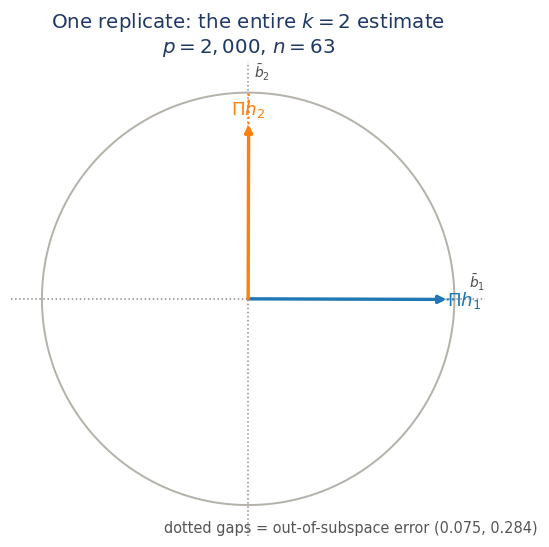

In [3]:
# ── Figure 1 · the whole estimate, on one disk ───────────────────────────────
fig, ax = plt.subplots(figsize=(5.6, 5.6))
draw_disk_frame(ax, labels=(r"$\bar b_1$", r"$\bar b_2$"))
for j, color in enumerate((C_F1, C_F2)):
    ax.annotate("", xy=tuple(C[:, j]), xytext=(0, 0), zorder=5,
                arrowprops=dict(arrowstyle="-|>", color=color, lw=2.2, shrinkA=0, shrinkB=0))
    ax.text(C[0, j] * 1.09, C[1, j] * 1.09, rf"$\Pi h_{j+1}$", color=color,
            fontsize=12, ha="center", va="center")
    # the radial gap to the circle IS the out-of-subspace error
    u = C[:, j] / radii[j]
    ax.plot([C[0, j], u[0]], [C[1, j], u[1]], color=color, lw=1.4, ls=":", zorder=4)
ax.text(0.5, -1.13, f"dotted gaps = out-of-subspace error "
                    f"({1-radii[0]**2:.3f}, {1-radii[1]**2:.3f})",
        transform=ax.transData, ha="center", fontsize=9.5, color=THEME.gray)
ax.set_title(f"One replicate: the entire $k=2$ estimate\n$p={P_DEMO:,}$, $n={N_DEMO}$",
             fontsize=THEME.title_fontsize, color=THEME.navy)
show(fig, "h2_fig1_one_disk")

## 2 · Rotating the frame spins the arrows — and moves nothing that matters

Replace $H$ by $HQ$ and the plotted pair becomes $CQ$: the two arrows swing together.
Each arrow's own radius changes, its angle to its own axis changes — and, because $C$
is a *projection* of an orthonormal frame rather than an orthogonal map, even the angle
*between* the two arrows changes. All three are basis-dependent. What survives is

$$\sum_j \lVert \Pi_{\mathcal B}h_j\rVert^2 = \lVert C\rVert_F^2 ,$$

a Frobenius norm, which $Q$ cannot move — together with $\mathrm{col}(H)$ itself, and
therefore the hedge. The table prints the three that move beside the one that does not.

In [4]:
def rot(theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s], [s, c]])

thetas = np.deg2rad([0, 20, 45, 70])
rows = []
for th in thetas:
    Cq = C @ rot(th)
    r = np.linalg.norm(Cq, axis=0)
    rows.append({
        "rotation (deg)": np.degrees(th),
        "|Pi h_1|": r[0], "|Pi h_2|": r[1],
        "angle h_1 to b_1 (deg)": np.degrees(np.arctan2(Cq[1, 0], Cq[0, 0])),
        "sum |Pi h_j|^2  (invariant)": (Cq ** 2).sum(),
        "angle between arrows (deg)": np.degrees(np.arccos(
            np.clip(Cq[:, 0] @ Cq[:, 1] / (r[0] * r[1]), -1, 1))),
    })
display(pd.DataFrame(rows).set_index("rotation (deg)").round(4))

,|Pi h_1|,|Pi h_2|,angle h_1 to b_1 (deg),sum |Pi h_j|^2 (invariant),angle between arrows (deg)
rotation (deg),,,,,
0.0,0.9620,0.8459,-0.1699,1.6409,90.0223
20.0,0.9490,0.8604,17.5797,1.6409,94.7546
45.0,0.9056,0.9060,41.1664,1.6409,97.3468
70.0,0.8602,0.9492,67.3639,1.6409,94.7207


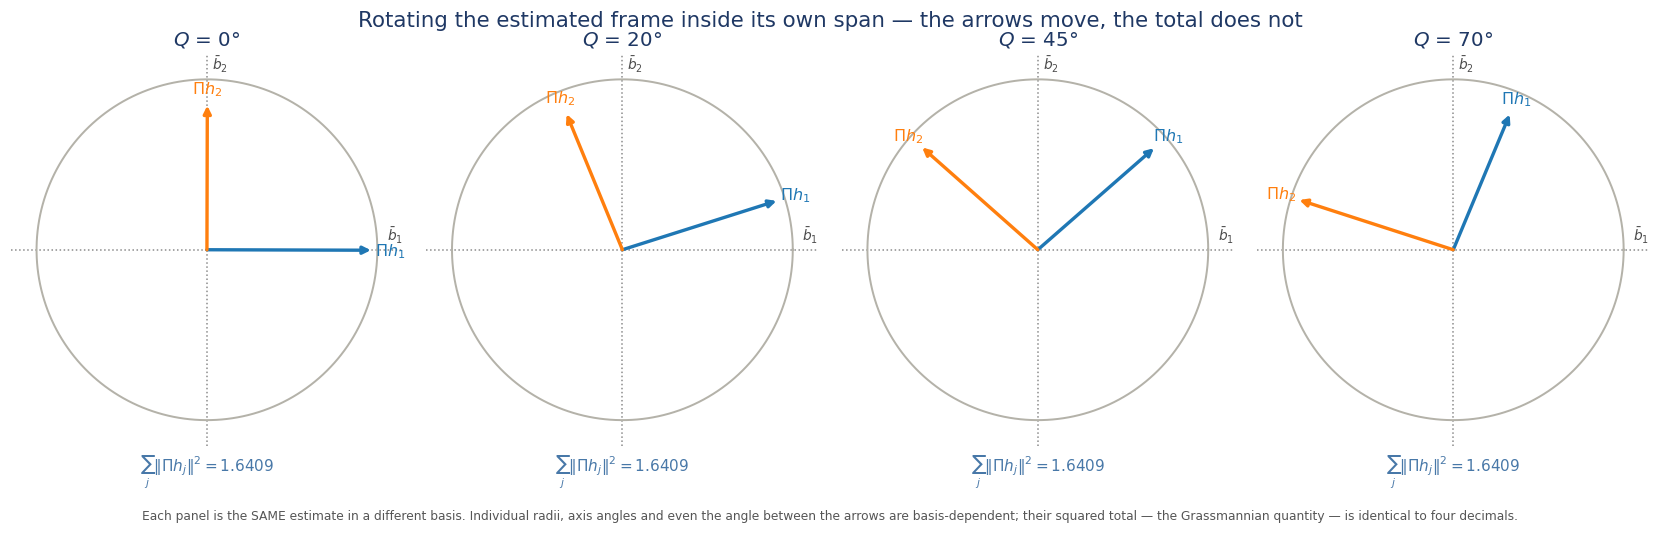

In [5]:
# ── Figure 2 · the same estimate under four rotations ────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(15.2, 4.2))
for ax, th in zip(axes, thetas):
    Cq = C @ rot(th)
    draw_disk_frame(ax, labels=(r"$\bar b_1$", r"$\bar b_2$"))
    for j, color in enumerate((C_F1, C_F2)):
        ax.annotate("", xy=tuple(Cq[:, j]), xytext=(0, 0), zorder=5,
                    arrowprops=dict(arrowstyle="-|>", color=color, lw=2.2, shrinkA=0, shrinkB=0))
        ax.text(Cq[0, j] * 1.12, Cq[1, j] * 1.12, rf"$\Pi h_{j+1}$", color=color,
                fontsize=10.5, ha="center", va="center")
    ax.set_title(rf"$Q$ = {np.degrees(th):.0f}$\degree$", fontsize=THEME.title_fontsize,
                 color=THEME.navy)
    ax.text(0, -1.30, rf"$\sum_j\Vert\Pi h_j\Vert^2 = {(Cq**2).sum():.4f}$",
            ha="center", fontsize=10, color=C_SUB)
fig.suptitle("Rotating the estimated frame inside its own span — the arrows move, the total does not",
             fontsize=THEME.title_fontsize + 1, color=THEME.navy)
fig.tight_layout()
fig.text(0.5, -0.10, "Each panel is the SAME estimate in a different basis. Individual radii, axis angles and even "
                     "the angle between the arrows are basis-dependent; their squared total — the Grassmannian "
                     "quantity — is identical to four decimals.",
         ha="center", va="top", fontsize=THEME.caption_fontsize, color=THEME.gray)
show(fig, "h2_fig2_rotations")

## 3 · The hedging consequence, drawn

Take a book $w$. Its factor exposure lives in the plane at $e=\bar Bw$ — the black
arrow. Now hedge:

- **$m=1$** (hedge "the first factor"): project out the single direction $\Pi h_1$.
  Which direction that *is* depends on the rotation, so the residual swings around
  the grey locus as $Q$ turns. This is the unbounded-rotation-error regime.
- **$m=2$** (hedge the whole block): project out the entire plane. $CQQ'=C$, so the
  residual is **one point**, the same for every $Q$ — and it sits near the origin,
  its distance from it being the out-of-subspace leakage alone.

Note what the printed range means. The $m=1$ residual runs from essentially the block
hedge's value up to the *unhedged* exposure itself: at the worst rotation the
single-factor hedge removes nothing at all. At the best one it nearly matches the block
hedge — but which rotation that is depends on $\bar B$, so it is not something a manager
can identify from the fit. The block hedge simply does not have the choice to get wrong.

In [6]:
w = standard_portfolios(P_DEMO)["equal_weight"]
e = b_pop @ w                      # exposure coordinates in the plane
a = H.T @ w                        # what the estimated frame sees

grid_th = np.linspace(0, 2 * np.pi, 361)
resid1 = np.array([e - (C @ rot(t))[:, 0] * (rot(t).T @ a)[0] for t in grid_th])
resid2 = e - C @ a                 # full block: independent of the rotation

print(f"unhedged exposure |e|              : {np.linalg.norm(e):.4f}")
print(f"m=1 residual |.| over rotations    : min {np.linalg.norm(resid1,axis=1).min():.4f}"
      f"   max {np.linalg.norm(resid1,axis=1).max():.4f}")
print(f"m=2 residual |.| (every rotation)  : {np.linalg.norm(resid2):.4f}")
_chk = max(np.linalg.norm((e - (C @ rot(t)) @ (rot(t).T @ a)) - resid2) for t in grid_th)
print(f"m=2 residual spread over rotations : {_chk:.2e}")

unhedged exposure |e|              : 0.8993
m=1 residual |.| over rotations    : min 0.0659   max 0.8993
m=2 residual |.| (every rotation)  : 0.0658
m=2 residual spread over rotations : 4.45e-16


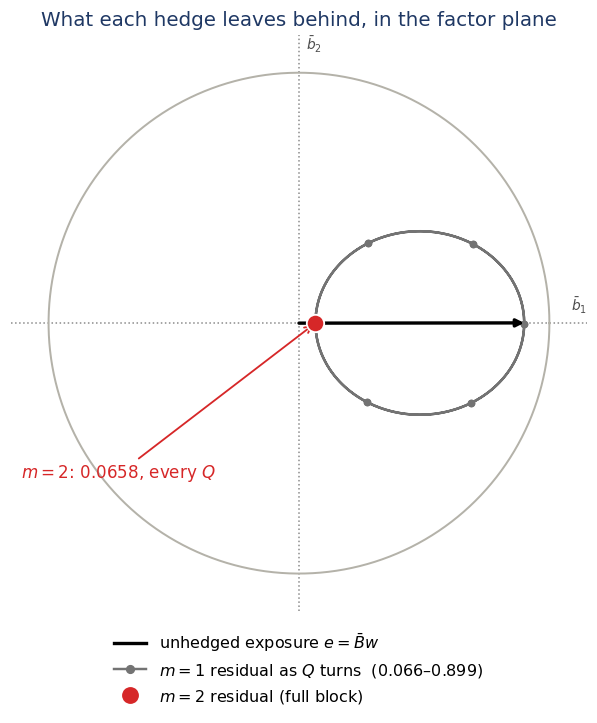

In [7]:
# ── Figure 3 · what each hedge removes ───────────────────────────────────────
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(6.8, 6.8))
lim = max(1.0, np.abs(resid1).max() * 1.1, abs(e).max() * 1.1)
draw_disk_frame(ax, radius=lim, labels=(r"$\bar b_1$", r"$\bar b_2$"))
ax.plot(resid1[:, 0], resid1[:, 1], color=C_REF, lw=1.6, zorder=3)
ax.scatter(resid1[::30, 0], resid1[::30, 1], s=16, color=C_REF, zorder=4)
ax.annotate("", xy=tuple(e), xytext=(0, 0), zorder=6,
            arrowprops=dict(arrowstyle="-|>", color="black", lw=2.2, shrinkA=0, shrinkB=0))
ax.scatter([resid2[0]], [resid2[1]], s=130, color=C_EST, edgecolor="white",
           lw=1.2, zorder=7, marker="o")
ax.annotate(rf"$m=2$: {np.linalg.norm(resid2):.4f}, every $Q$",
            xy=tuple(resid2), xytext=(-0.72, -0.62), textcoords="data",
            fontsize=11, color=C_EST, ha="center",
            arrowprops=dict(arrowstyle="->", color=C_EST, lw=1.2))
ax.legend(handles=[
    Line2D([], [], color="black", lw=2.2, label=r"unhedged exposure $e=\bar Bw$"),
    Line2D([], [], color=C_REF, lw=1.6, marker="o", ms=5,
           label=rf"$m=1$ residual as $Q$ turns  ({np.linalg.norm(resid1,axis=1).min():.3f}"
                 rf"–{np.linalg.norm(resid1,axis=1).max():.3f})"),
    Line2D([], [], color=C_EST, lw=0, marker="o", ms=10, label=r"$m=2$ residual (full block)"),
], fontsize=10.5, frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.01), ncol=1)
ax.set_title("What each hedge leaves behind, in the factor plane",
             fontsize=THEME.title_fontsize, color=THEME.navy)
show(fig, "h2_fig3_hedge_residual")

## 4 · Growing $p$: the cloud tightens onto the axes

One last sweep, the shared-$B$ design as everywhere else in this repo. Each dot is a
replicate's $\Pi h_j$. As $p$ grows the clouds collapse onto their own axes — the
in-plane rotation shrinks — while the radius stops short of the circle by the
out-of-subspace floor, which $p$ does **not** remove (it is set by $n$).

In [8]:
class CoordAnalysis:
    # Per-replicate arrow coordinates C = B_bar H, gauge-fixed.

    def __init__(self, b_pop, B):
        self.b_pop, self.B = b_pop, B

    def analyze(self, context) -> dict:
        Y = context.security_returns.T
        Y = Y - Y.mean(axis=1, keepdims=True)
        H, _, _ = sample_pcs(Y, context.k, center=False)
        b_pop, H = gauge(self.b_pop, self.B, H)
        return {"C": b_pop @ H}


class CoordExperiment(BaseExperiment):
    def cell_setup(self, model, n, p):
        _, b_pop = compute_true_eigenvalues(model, model.k)
        return [CoordAnalysis(b_pop, model.B)]

    def record(self, n, p, merged):
        C = merged["C"]
        return [{"n": n, "p": p, "j": j + 1, "hb1": float(C[0, j]), "hb2": float(C[1, j]),
                 "oos": float(1.0 - (C[:, j] ** 2).sum())} for j in range(C.shape[1])]


P_GRID, N_REPS, SEED = [100, 500, 5000, 50_000], 300, 20260511
design = DesignSpec(n_values=[63], p_values=P_GRID, n_reps=N_REPS, random_seed=SEED,
                    sampling="nested", nest_time=True, shared_loadings=True, **NORMAL)

_pq = OUT_DIR / "h2_two_factor_coords.parquet"
if _pq.exists():
    df = pd.read_parquet(_pq)
    print(f"loaded cached sweep ({len(df):,} rows)")
else:
    print("running sweep...")
    df = run_experiment(model_spec, design, CoordExperiment(), progress=True)
    df.to_parquet(_pq)
    print(f"ran sweep ({len(df):,} rows)")

display(df.groupby(["p", "j"])[["oos"]].mean().round(4).unstack()
          .rename_axis(columns=["", "factor"]))

loaded cached sweep (2,400 rows)


oos        
factor       1       2
p                     
100     0.0780  0.3954
500     0.0781  0.2956
5000    0.0770  0.3012
50000   0.0768  0.2974

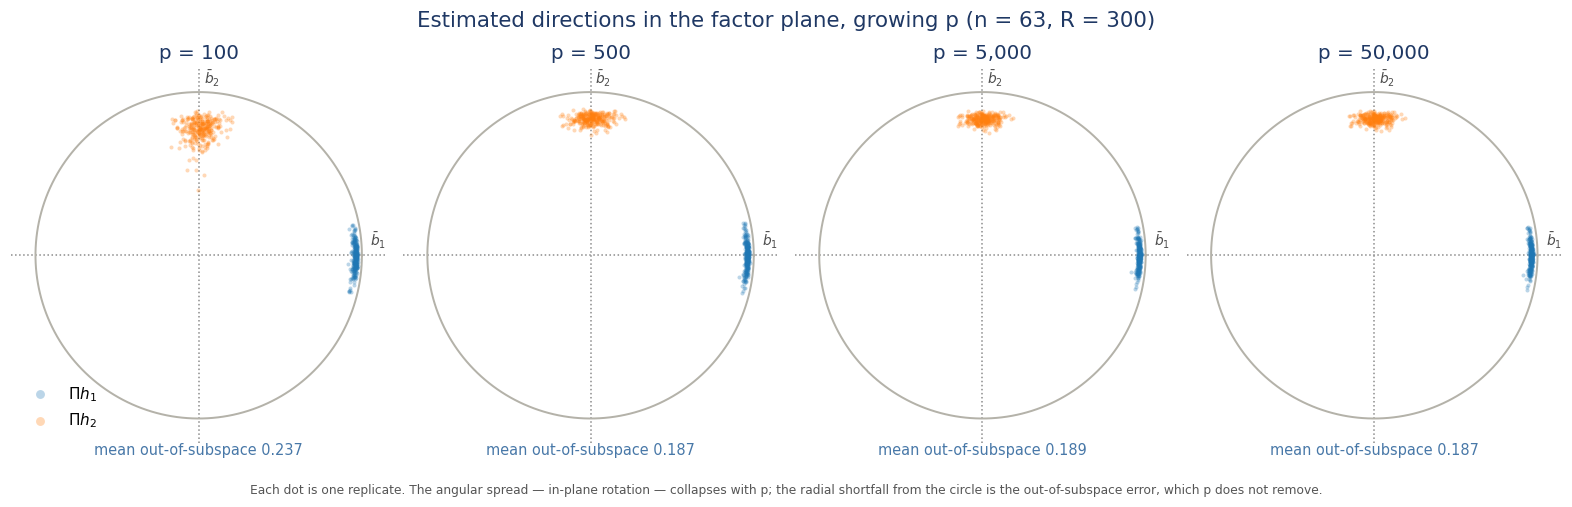

In [9]:
# ── Figure 4 · the cloud over growing p ──────────────────────────────────────
fig, axes = plt.subplots(1, len(P_GRID), figsize=(3.6 * len(P_GRID), 4.3))
for ax, p in zip(axes, P_GRID):
    draw_disk_frame(ax, labels=(r"$\bar b_1$", r"$\bar b_2$"))
    for j, color in enumerate((C_F1, C_F2), start=1):
        s = df[(df.p == p) & (df.j == j)]
        ax.scatter(s.hb1, s.hb2, s=7, color=color, alpha=0.30, lw=0, zorder=3,
                   label=rf"$\Pi h_{j}$" if p == P_GRID[0] else None)
    ax.set_title(f"p = {p:,}", fontsize=THEME.title_fontsize, color=THEME.navy)
    ax.text(0, -1.22, f"mean out-of-subspace {df[df.p==p].oos.mean():.3f}",
            ha="center", fontsize=9.5, color=C_SUB)
axes[0].legend(fontsize=10, frameon=False, loc="lower left", markerscale=2.2)
fig.suptitle(f"Estimated directions in the factor plane, growing p (n = 63, R = {N_REPS})",
             fontsize=THEME.title_fontsize + 1, color=THEME.navy)
fig.tight_layout()
fig.text(0.5, -0.02, "Each dot is one replicate. The angular spread — in-plane rotation — collapses with p; the "
                     "radial shortfall from the circle is the out-of-subspace error, which p does not remove.",
         ha="center", va="top", fontsize=THEME.caption_fontsize, color=THEME.gray)
show(fig, "h2_fig4_cloud_over_p")

## What to take from it

The disk makes the split in `ex-h1` visible rather than algebraic:

- **Radial shortfall = out-of-subspace error.** The gap from each arrow tip to the
  unit circle. A block hedge pays this, and it is the quantity Corollary 1 estimates
  from data as $\sum_j\hat\ell/\hat\theta_j$. Figure 4 shows $p$ does not shrink it.
- **Angular position = in-plane rotation.** Basis-dependent, unbounded in theory, and
  Figure 2 shows it moving freely while the squared total stays fixed.
- **The hedge sees only the plane.** Figure 3 is the whole argument in one panel: the
  $m=1$ residual rides a locus as the frame turns; the $m=2$ residual is a single
  point that no rotation can move.

The one thing the $k=2$ picture cannot show is the blind spot from `ex-h1`: a book
with $\Pi_H w=0$ has *no* arrow in this plane to draw, which is precisely why the
estimated model reports it as factor-neutral.